# Introducción a la Ciencia de Datos: Tarea 1

Este notebook contiene el código de base para realizar la Tarea 1 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y la librería Pandas. Si no tiene ninguna familiaridad con la librería, se recomienda realizar algún tutorial introductorio (ver debajo).
También se espera que los alumnos sean proactivos a la hora de consultar las documentaciones de las librerías y del lenguaje, para entender el código provisto.
Además de los recursos provistos en la [página del curso](https://eva.fing.edu.uy/course/view.php?id=1378&section=1), los siguientes recursos le pueden resultar interesantes:
 - [Pandas getting started](https://pandas.pydata.org/docs/getting_started/index.html#getting-started) y [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html): Son parte de la documentación en la página oficial de Pandas.
 - [Kaggle Learn](https://www.kaggle.com/learn): Incluye tutoriales de Python y Pandas.


Si desea utilizar el lenguaje R y está dispuesto a no utilizar (o traducir) este código de base, también puede hacerlo.

En cualquier caso, **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://github.com/DonBraulio/introCD)).

In [1]:
from time import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datasets import load_dataset

# Agregue aqui el resto de las librerias que necesite
# from ...
# import ...

## Descarga del dataset
En esta tarea se utilizará una base de datos abierta que contiene artículos de noticias publicados en distintos medios de prensa, con la finalidad de realizar una clasificación de textos según el medio de prensa al que pertenecen. [Link](https://huggingface.co/datasets/rjac/all-the-news-2-1-Component-one?utm_source=chatgpt.com) \
\
Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas. La constante `DATA_PATH` determina la ubicación donde se almacenaran los datos. \
\
El dataset entero pesa ~8.3gb. Para evitar demoras en la descarga/procesamiento vamos a utilizar el parámetro `streaming=True` y hacer un muestreo aleatorio para descargar una porción de los datos lo más representativa posible.

In [2]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train",cache_dir="../data")
df = ds.to_pandas()

## Lectura de Datos

In [3]:
# Veamos las primeras filas del DataFrame
df.head()

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,NaN,BRIEF-Teva Says Fremanezumab Marketing Authori...,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,https://www.reuters.com/article/brief-teva-say...,Healthcare,Reuters
1,2,2,2018-05-01,2018,5.0,1,NaN,CMS' Verma says it’s time health care caught u...,The head of the Centers for Medicare and Medic...,https://www.cnbc.com/2018/04/30/cms-verma-says...,Health and Science,CNBC
2,3,3,2017-08-14,2017,8.0,14,Harper Neidig,Uber investor accuses Kalanick of 'undermining...,"Benchmark, the venture capital firm that helpe...",https://thehill.com/policy/technology/346520-u...,NaN,The Hill
3,4,4,2017-04-03 00:00:00,2017,4.0,3,NaN,Chad Johnson Catches Uno Touchdown In Mexican ...,VIVA OCHOCINCO!!!!! Chad Johnson made his triu...,https://www.tmz.com/2017/04/03/chad-johnson-me...,NaN,TMZ
4,5,5,2018-12-27 19:20:08,2018,12.0,27,Aja Romano,"Hopepunk, explained: the storytelling trend th...",Literary and artistic movements often arise sp...,https://www.vox.com/2018/12/27/18137571/what-i...,NaN,Vox


In [4]:
# Veamos información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   idx          30213 non-null  int64
 1   article_idx  30213 non-null  int64
 2   date         30213 non-null  str  
 3   year         30213 non-null  str  
 4   month        30213 non-null  str  
 5   day          30213 non-null  str  
 6   author       18808 non-null  str  
 7   title        30213 non-null  str  
 8   article      29037 non-null  str  
 9   url          30072 non-null  str  
 10  section      19981 non-null  str  
 11  publication  30072 non-null  str  
dtypes: int64(2), str(10)
memory usage: 96.1 MB


# Parte 1: Cargado y Limpieza de Datos

## A. Exploración de Datos
Analice el contenido del DataFrame. Reporte si existen datos faltantes en algún campo, o cualquier otro problema de calidad de datos que encuentre. \
En particular, analice la cantidad de artículos por medio de prensa, y a partir de este punto trabaje con los **cinco medios con mayor cantidad de artículos**.

In [5]:
# Análisis simple de datos faltantes por columna
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "faltantes": missing_count,
    "porcentaje": missing_pct
}).sort_values("faltantes", ascending=False)

print("Datos faltantes por columna:")
print(missing_summary)

# Chequeo rápido de calidad de datos: filas duplicadas completas
duplicadas = df.duplicated().sum()
print(f"\nFilas duplicadas completas: {duplicadas}")


Datos faltantes por columna:
             faltantes  porcentaje
author           11405       37.75
section          10232       33.87
article           1176        3.89
url                141        0.47
publication        141        0.47
idx                  0        0.00
article_idx          0        0.00
date                 0        0.00
year                 0        0.00
month                0        0.00
day                  0        0.00
title                0        0.00

Filas duplicadas completas: 0


In [6]:
# Cantidad de artículos por medio de prensa
articles_per_publication = df["publication"].value_counts()
print(articles_per_publication)

# Tome los 5 medios con más artículos
top_5_publications = articles_per_publication.head(5).index.tolist()
df_top_5 = df[df["publication"].isin(top_5_publications)].copy()

print("\nTop 5 medios:")
print(top_5_publications)
print(f"Filas en df_top_5: {len(df_top_5)}")

publication
Reuters               9431
The New York Times    2840
CNBC                  2623
The Hill              2349
People                1528
CNN                   1446
Refinery 29           1236
Vice                  1154
Mashable              1045
Business Insider       660
The Verge              594
TechCrunch             568
TMZ                    552
Vox                    549
Axios                  538
Politico               518
Washington Post        468
Buzzfeed News          376
Gizmodo                329
Economist              303
Wired                  231
Fox News               227
Vice News              187
New Republic           145
Hyperallergic          123
New Yorker              52
Name: count, dtype: int64

Top 5 medios:
['Reuters', 'The New York Times', 'CNBC', 'The Hill', 'People']
Filas en df_top_5: 18771


## B. Visualización temporal
Genere una gráfica que permita visualizar los artículos de los cinco medios a lo largo del tiempo, con alguna escala temporal adecuada. \
Comente si se identifican momentos de mayor actividad o patrones temporales en la cobertura.

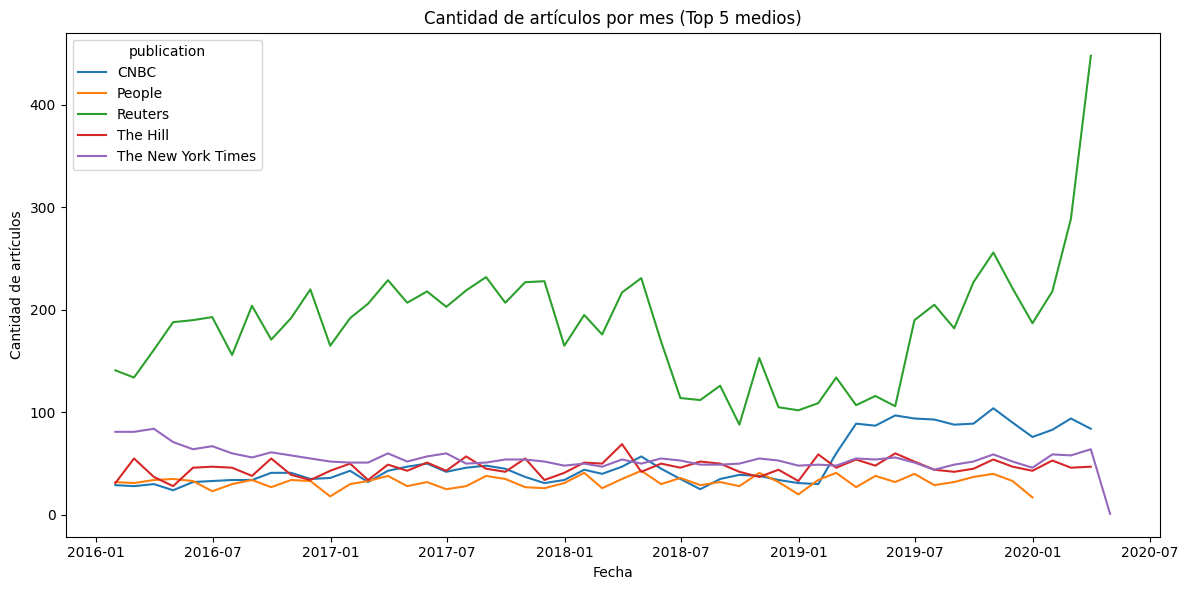

Medios incluidos en la gráfica: ['CNBC', 'People', 'Reuters', 'The Hill', 'The New York Times']


In [7]:
# Visualización simple de cantidad de artículos por mes y medio

# Convertimos fechas con tolerancia a formatos mixtos
# NOTA: en pandas reciente conviene usar format="mixed" cuando hay formatos distintos
# Sin esto perdemos algunos publication porque las fechas tienen formato distinto
df_top_5["date_parsed"] = pd.to_datetime(
    df_top_5["date"],
    format="mixed",
    errors="coerce"
)

# Nos quedamos con filas válidas de fecha
plot_df = df_top_5.dropna(subset=["date_parsed"]).copy()

# Agrupamos por fin de mes y medio de prensa (pandas nuevo: "ME")
articles_by_month = (
    plot_df
    .groupby([pd.Grouper(key="date_parsed", freq="ME"), "publication"])
    .size()
    .reset_index(name="articles")
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=articles_by_month,
    x="date_parsed",
    y="articles",
    hue="publication"
)

plt.title("Cantidad de artículos por mes (Top 5 medios)")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de artículos")
plt.tight_layout()
plt.show()

print("Medios incluidos en la gráfica:", sorted(articles_by_month["publication"].unique().tolist()))

## C. Limpieza de texto y conteo de palabras
Se provee la función `clean_text(...)` que realiza parte de la normalización del texto. \
**Complete la función** agregando signos de puntuación faltantes y cualquier otra normalización que considere oportuna. \
Compruebe el resultado observando el contenido del DataFrame procesado. Comente todas las transformaciones que haya agregado y justifique.

In [8]:
def clean_text(df, column_name):

    # Rellenar faltantes para evitar errores en operaciones de texto
    result = df[column_name].fillna("")

    # Eliminar primeras palabras hasta el primer "\n"
    result = result.str.replace(r"^[^\n]*\n", "", regex=True)

    # Convertir todo a minúsculas
    result = result.str.lower()

    # Reemplazar signos de puntuación por espacio (versión simple)
    for punc in ["[", "]", "\n", ",", ".", ":", ";", "?", "!", "(", ")", '"', "'", "-"]:
        result = result.str.replace(punc, " ", regex=False)

    # Colapsar espacios múltiples
    result = result.str.replace(r"\s+", " ", regex=True).str.strip()

    return result

In [9]:
# Aplicamos clean_text sobre el cuerpo del artículo y guardamos en una nueva columna
# (también podría usarse "title" o combinar ambas columnas)
df_top_5["CleanText"] = clean_text(df_top_5, "article")

# Vista rápida para validar
print(df_top_5[["publication", "article", "CleanText"]].head(10))


           publication                                            article  \
0              Reuters  Feb 2 (Reuters) - Teva Pharmaceutical Industri...   
1                 CNBC  The head of the Centers for Medicare and Medic...   
2             The Hill  Benchmark, the venture capital firm that helpe...   
5                 CNBC  (Updates with new first paragraph, adds backgr...   
6              Reuters  TORONTO, Dec 4 (Reuters) - Bank of Montreal on...   
8   The New York Times  Calculator Sure, if you choose the right place...   
9   The New York Times  BOGOTÁ, Colombia — Colombia is investigating a...   
11            The Hill  Virginia Gov. Terry McAuliffe (D) included a d...   
12                CNBC  Italy's Finance Minister, Pier Carlo Padoan, h...   
13            The Hill  Former Starbucks CEO Howard Schultz has recrui...   

                                            CleanText  
0   feb 2 reuters teva pharmaceutical industries l...  
1   the head of the centers for medicare

## D. Elección de campos de texto
Discuta si conviene trabajar con:
- sólo el cuerpo del artículo,
- sólo el título,
- o una combinación de ambos.

Justifique brevemente su decisión.

Conviene trabajar con una combinación de title y article. El cuerpo del artículo contiene mucha más información léxica y de estilo, por lo que debería ser la principal fuente para caracterizar cada medio. Sin embargo, el título también aporta señales relevantes: resume el tema, refleja decisiones editoriales y además no presenta faltantes en la muestra, mientras que algunos artículos sí tienen el cuerpo vacío o faltante.

Usar solo el título sería demasiado limitado, porque son textos muy cortos y pueden depender mucho del tema puntual de la noticia. Usar solo el cuerpo es una opción razonable, pero perdería información útil en los casos donde el artículo falta o donde el título contiene una formulación distintiva del medio.

Por eso, usaría un campo combinado, por ejemplo title + " " + article, aplicando la misma limpieza a ambos. De todos modos, habría que controlar que esta combinación no introduzca pistas directas del medio, como nombres del periódico, URLs, firmas o plantillas repetidas, porque eso haría que una futura clasificación aprenda atajos en lugar de diferencias reales de contenido o estilo.

## E. Pistas que identifican al medio de prensa
Analice si en el texto aparecen pistas que identifiquen de manera directa al medio de prensa (nombres del medio, URLs, firmas, nombres de secciones, plantillas repetidas, etc.). \
En caso de encontrarlas, comente si considera conveniente eliminarlas o reducir su impacto, y justifique su decisión.

In [10]:
# Buscamos pistas directas simples: menciones al nombre de cada medio en el texto.
# Para hacerlo simple, usamos el texto limpio ya calculado en CleanText.

mentions = []

for publication in top_5_publications:
    name = publication.lower()
    count = df_top_5["CleanText"].str.contains(name, regex=False, na=False).sum()
    mentions.append({
        "medio_mencionado": publication,
        "articulos_que_lo_mencionan": count
    })

mentions_df = pd.DataFrame(mentions)
print(mentions_df)

# Miramos algunos ejemplos donde el propio medio aparece mencionado en el artículo.
for publication in top_5_publications:
    name = publication.lower()
    examples = df_top_5[
        (df_top_5["publication"] == publication) &
        (df_top_5["CleanText"].str.contains(name, regex=False, na=False))
    ][["publication", "CleanText", "title", "url"]].head(3)

    print("\nEjemplos para", publication)
    display(examples)

     medio_mencionado  articulos_que_lo_mencionan
0             Reuters                        9299
1  The New York Times                         722
2                CNBC                         961
3            The Hill                        2392
4              People                        5938

Ejemplos para Reuters


,publication,CleanText,title,url
0,Reuters,feb 2 reuters teva pharmaceutical industries l...,BRIEF-Teva Says Fremanezumab Marketing Authori...,https://www.reuters.com/article/brief-teva-say...
6,Reuters,toronto dec 4 reuters bank of montreal on tues...,Bank of Montreal's quarterly earnings beat mar...,https://www.reuters.com/article/bmo-results/ba...
15,Reuters,houston reuters an outage on a major pipeline ...,Crude market takes U.S. Seaway pipeline outage...,http://www.reuters.com/article/us-pipeline-ope...



Ejemplos para The New York Times


,publication,CleanText,title,url
8,The New York Times,calculator sure if you choose the right place ...,Are Beach House Rentals Profitable?,https://www.nytimes.com/2019/05/23/realestate/...
25,The New York Times,opinion the remnants of decades of conflict ar...,Opinion | When War Is More Dangerous for Civil...,https://www.nytimes.com/2018/03/07/opinion/the...
45,The New York Times,footsteps in and around stockholm the secretiv...,"In Search of Hilma af Klint, Who Upended Art H...",https://www.nytimes.com/2019/10/21/travel/stoc...



Ejemplos para CNBC


,publication,CleanText,title,url
12,CNBC,italy s finance minister pier carlo padoan has...,Bailout for Italian banks has been 'absolutely...,https://www.cnbc.com/2016/09/02/weak-global-gr...
49,CNBC,the kremlin said on wednesday it was total non...,Kremlin says it has no compromising dossier on...,https://www.cnbc.com/2017/01/11/kremlin-says-i...
146,CNBC,lyft s week is off to a dreary start as the st...,Lyft's stock continues to dive after its disma...,https://www.cnbc.com/2019/04/15/lyfts-stock-co...



Ejemplos para The Hill


,publication,CleanText,title,url
2,The Hill,benchmark the venture capital firm that helped...,Uber investor accuses Kalanick of 'undermining...,https://thehill.com/policy/technology/346520-u...
11,The Hill,virginia gov terry mcauliffe d included a dig ...,McAuliffe jabs Pence over GOP healthcare bill ...,https://thehill.com/homenews/senate/342124-vir...
13,The Hill,former starbucks ceo howard schultz has recrui...,Schultz recruiting GOP insiders ahead of possi...,https://thehill.com/homenews/campaign/432954-s...



Ejemplos para People


,publication,CleanText,title,url
59,People,nearly $100 000 in jewelry that once belonged ...,Bernie and Ruth Madoff's Antique Jewelry Being...,https://people.com/crime/bernie-and-ruth-madof...
89,People,a doctor’s visit is no big deal when you’ve go...,Chip Gaines and Son Share Heartwarming Smile a...,https://people.com/parents/joanna-gaines-chip-...
167,People,posh spice still has the moves former pop star...,Victoria Beckham Dances with Cast of Tina: The...,https://people.com/style/watch-victoria-beckha...


In [11]:
# Analisis un poco mas completo de posibles pistas directas del medio.
# La idea es mirar URLs, firmas/autores, secciones y textos repetidos.

from urllib.parse import urlparse

# 1) URLs: el dominio suele identificar directamente al medio.
df_top_5["url_domain"] = df_top_5["url"].fillna("").apply(
    lambda x: urlparse(x).netloc.replace("www.", "") if x else ""
)

print("Dominios mas frecuentes por medio:")
for publication in top_5_publications:
    print("\n", publication)
    display(
        df_top_5[df_top_5["publication"] == publication]["url_domain"]
        .value_counts()
        .head(5)
        .reset_index(name="cantidad")
        .rename(columns={"url_domain": "dominio"})
    )

# 2) Firmas/autores: algunas firmas pueden ser muy propias de un medio.
print("\nAutores mas frecuentes por medio:")
for publication in top_5_publications:
    print("\n", publication)
    display(
        df_top_5[df_top_5["publication"] == publication]["author"]
        .fillna("SIN AUTOR")
        .value_counts()
        .head(10)
        .reset_index(name="cantidad")
        .rename(columns={"author": "autor"})
    )

# 3) Secciones: si una seccion aparece solo en un medio, tambien puede ser una pista.
print("\nSecciones mas frecuentes por medio:")
for publication in top_5_publications:
    print("\n", publication)
    display(
        df_top_5[df_top_5["publication"] == publication]["section"]
        .fillna("SIN SECCION")
        .value_counts()
        .head(10)
        .reset_index(name="cantidad")
        .rename(columns={"section": "seccion"})
    )

# 4) Plantillas repetidas: miramos comienzos repetidos de articulos.
# Esto no detecta todos los casos, pero sirve para encontrar frases tipo firma o formato fijo.
df_top_5["article_start"] = (
    df_top_5["article"]
    .fillna("")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str[:120]
)

repeated_starts = (
    df_top_5[df_top_5["article_start"] != ""]
    .groupby(["publication", "article_start"])
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)

print("\nComienzos de articulos repetidos mas frecuentes:")
display(repeated_starts[repeated_starts["cantidad"] > 1].head(20))


Dominios mas frecuentes por medio:

 Reuters


,dominio,cantidad
0,reuters.com,9431



 The New York Times


,dominio,cantidad
0,nytimes.com,2794
1,cn.nytimes.com,9
2,learning.blogs.nytimes.com,6
3,wordplay.blogs.nytimes.com,5
4,artsbeat.blogs.nytimes.com,5



 CNBC


...

,seccion,cantidad
0,SIN SECCION,2349



 People


,seccion,cantidad
0,tv,280
1,movies,153
2,style,136
3,crime,130
4,celebrity,112
5,music,100
6,royals,83
7,parents,72
8,pets,67
9,food,60



Comienzos de articulos repetidos mas frecuentes:


,publication,article_start,cantidad
15310,The Hill,View the discussion thread. The Hill 1625 K St...,51
14495,The Hill,President TrumpDonald John TrumpFacebook relea...,38
14505,The Hill,President TrumpDonald John TrumpTrump pushes b...,37
3532,People,"PEOPLE Now airs live, Monday through Friday, f...",18
13798,The Hill,Democratic strategist Antjuan Seawright said T...,14
13819,The Hill,Donald TrumpDonald John TrumpPossible GOP chal...,13
14750,The Hill,Senate Majority Leader Mitch McConnellAddison ...,9
14052,The Hill,Hillary ClintonHillary Diane Rodham ClintonTop...,9
14051,The Hill,Hillary ClintonHillary Diane Rodham ClintonLew...,8
14705,The Hill,Sen. Elizabeth WarrenElizabeth Ann WarrenHarry...,8


Los datos revelan varias pistas directas de identificación del medio en el texto:

**1. Dateline de Reuters (la más fuerte)**
Casi el 100% de los artículos de Reuters (9.299 de 9.431) contienen la palabra "reuters" en el cuerpo del texto, debido a la plantilla `LUGAR, Fecha (Reuters) —` que encabeza cada nota. Es una firma estructural que permitiría identificar el medio con una sola regla simple.

**2. URLs**
El campo `url` contiene el dominio del medio (`reuters.com`, `nytimes.com`, `cnbc.com`, etc.), lo que permite identificar el origen con exactitud perfecta. No afecta el texto del artículo, pero sería data leakage si se usara como feature.

**3. Nombre del medio en el texto**
Además de Reuters, The Hill aparece en 2.392 artículos y CNBC en 961. People suma 5.938 menciones, aunque "people" es una palabra muy común en inglés y la mayoría de esas ocurrencias no refieren al medio.

**4. Plantillas repetidas**
The Hill tiene artículos con encabezados de newsletter repetidos decenas de veces ("Welcome to Hillicon Valley", "Welcome to OVERNIGHT CYBERSECURITY", "To view past editions of The Hill's 12:30 Report"), y People tiene plantillas del tipo "PEOPLE Now airs live, Monday through Friday". Estos comienzos identifican el medio de forma casi perfecta.

**5. Secciones y autores**
Las secciones son propias de cada medio (The Hill no tiene sección definida en ningún artículo; las secciones de People como "royals" o "pets" son exclusivas de ese medio). Algunos autores también publican exclusivamente en un solo outlet.

**¿Conviene eliminarlas?**

Sí. Si el objetivo es clasificar por estilo o contenido editorial real, mantener estas pistas haría que el clasificador aprenda atajos triviales en lugar de diferencias genuinas de lenguaje o enfoque temático. El modelo tendría alta accuracy pero sin generalización ni valor analítico.

Las acciones concretas recomendadas son:
- Eliminar el dateline de Reuters con una regex del tipo `^[A-Z ,\d]+ \(Reuters\)[^—]*—\s*`
- No usar las columnas `url`, `section` ni `author` como features
- Eliminar o normalizar los encabezados de newsletter repetidos de The Hill y People
- Evaluar filtrar ocurrencias del nombre exacto del medio en el texto, con cuidado de no eliminar usos legítimos de palabras comunes como "people"

## F. Restricción por sección o período temporal
Evalúe si conviene restringir el análisis a artículos de una misma sección temática o de un período temporal acotado, con el objetivo de reducir el efecto del tema sobre una futura tarea de clasificación por medio. \
No es necesario implementar esta restricción, pero sí discutir sus posibles ventajas y desventajas.

*TODO: Escriba su análisis en el informe.*

# Parte 2: Conteo de Palabras y Visualizaciones

## A. Palabras más frecuentes por medio
Realice una visualización que permita comparar las palabras más frecuentes de cada uno de los cinco medios de prensa. \
Sin necesidad de implementarlo, proponga ideas para modificar esta visualización con el fin de encontrar diferencias entre secciones temáticas, fechas, o tipos de noticias.

In [ ]:
# TODO: Realice una visualización que permita comparar las palabras más frecuentes
# de cada uno de los cinco medios de prensa.
# - ¿Encuentra algún problema en los resultados?


## B. Medios con mayor cantidad de palabras
Corra el código que permite encontrar los medios con mayor cantidad de palabras. \
En caso de encontrar algún problema luego de realizar la visualización, comente a qué se debe y proponga formas de resolverlo.

In [ ]:
# TODO: Busque los medios con mayor cantidad de palabras

## C. Matriz de menciones entre medios
Construya una matriz de 5×5, donde cada fila y columna corresponden a un medio de prensa, y la entrada (i,j) contiene la cantidad de veces que el medio *i* menciona al medio *j*. \
\
**Opcional:** genere un grafo dirigido con esa matriz de adyacencia para visualizar las menciones. Puede ser útil la biblioteca `networkx`.

In [ ]:
# TODO: Construya una matriz de 5x5, donde cada fila y columna corresponden a un medio de prensa,
# y la entrada (i,j) contiene la cantidad de veces que el medio "i" menciona al medio "j".

# mentions_matrix = ...


In [ ]:
# Opcional: Genere un grafo dirigido con la matriz de adyacencia para visualizar las menciones.
# Puede ser útil la biblioteca networkx.



## D. Preguntas propuestas
Proponga al menos tres preguntas que se podrían intentar responder a partir de estos datos, y mencione posibles caminos para responderlas, sin implementar nada.

*TODO: Escriba sus preguntas y posibles caminos en el informe.*